# 앙상블 가중치 비교 & 비트코인 가격 예측 적중률 분석

## 목적
1. **FinBERT:Gemma 가중치 5가지(0:100 ~ 100:0)** 중 감정 분석에 가장 적합한 비율 탐색
2. 뉴스 감성 분석 결과로 **비트코인 가격 방향(상승/하락) 예측 적중률** 수치 확인

## 노트북 구성
1. 환경 설정
2. 데이터 로드 (뉴스 + 가격)
3. FinBERT + Gemma 개별 분석
4. 가중치별 앙상블 점수 계산 (Gemma 미실행 시 자동 스킵)
5. 가중치별 분포 비교


---
## 1. 환경 설정


In [1]:
# ── 표준 라이브러리 ──────────────────────────────────────────────────────
import os
import sys
import time
import warnings
from pathlib import Path

# ── 서드파티 ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv
from scipy import stats

# ── matplotlib 한글 폰트 설정 (Windows: Malgun Gothic) ──────────────────
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# ── 프로젝트 루트를 sys.path 에 추가 ────────────────────────────────────
PROJECT_ROOT = Path('../').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')

DATA_RAW  = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC = PROJECT_ROOT / 'data' / 'processed'

print(f'프로젝트 루트: {PROJECT_ROOT}')


프로젝트 루트: C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis


---
## 2. 데이터 로드

뉴스 감성 데이터(news_sentiment.csv)와 가격-감성 연동 데이터(merged_analysis.csv)를 로드한다.


In [2]:
# ── 뉴스 감성 데이터 로드 ────────────────────────────────────────────────
SENTIMENT_FILE = DATA_PROC / 'news_sentiment.csv'
MERGED_FILE    = DATA_PROC / 'merged_analysis.csv'

news_df = pd.read_csv(SENTIMENT_FILE, parse_dates=['published_at'])
merged_df = pd.read_csv(MERGED_FILE, parse_dates=['window_start', 'open_time'])

print(f'뉴스 감성 데이터: {len(news_df)}건')
print(f'  컬럼: {list(news_df.columns)}')
print(f'\n가격-감성 병합 데이터: {len(merged_df)}건')
print(f'  컬럼: {list(merged_df.columns)}')
print(f'\n기간: {merged_df["window_start"].min()} ~ {merged_df["window_start"].max()}')


뉴스 감성 데이터: 145건
  컬럼: ['title', 'url', 'source', 'published_at', 'finbert_positive_prob', 'finbert_neutral_prob', 'finbert_negative_prob', 'score', 'is_valid', 'sentiment_label', 'finbert_score', 'gemma_positive_prob', 'gemma_neutral_prob', 'gemma_negative_prob', 'gemma_score', 'ensemble_score', 'agreement_score', 'body']

가격-감성 병합 데이터: 32건
  컬럼: ['window_start', 'window_score', 'news_count', 'confidence_sum', 'open_time', 'close', 'return_5m', 'return_15m', 'return_30m', 'return_60m']

기간: 2026-04-17 19:10:00+00:00 ~ 2026-04-20 06:45:00+00:00


In [3]:
# ── 가격 데이터 확인 ─────────────────────────────────────────────────────
print('=== 가격-감성 병합 데이터 샘플 ===')
print(merged_df[['window_start', 'window_score', 'return_5m', 'return_15m', 'return_30m', 'return_60m']].head(10).to_string(index=False))

print(f'\n수익률 통계 (단위: %)')
returns_cols = ['return_5m', 'return_15m', 'return_30m', 'return_60m']
print(merged_df[returns_cols].describe().round(4).to_string())


=== 가격-감성 병합 데이터 샘플 ===
             window_start  window_score  return_5m  return_15m  return_30m  return_60m
2026-04-17 19:10:00+00:00      0.841081   0.246276    0.282296    0.334704    0.402348
2026-04-17 19:20:00+00:00     -0.081628  -0.032559   -0.199062   -0.063967    0.061421
2026-04-17 21:10:00+00:00      0.925522  -0.007950    0.124368   -0.069856    0.177006
2026-04-17 21:30:00+00:00     -0.251409  -0.006603   -0.019744    0.017250   -0.026088
2026-04-18 00:45:00+00:00      0.929989   0.198563    0.228191    0.406661    0.320920
2026-04-18 02:45:00+00:00      0.451139  -0.032711   -0.053612   -0.092273   -0.191763
2026-04-18 04:45:00+00:00      0.658495   0.066019    0.145693    0.203002    0.144590
2026-04-18 07:30:00+00:00     -0.613781  -0.019963   -0.099453   -0.103539   -0.512081
2026-04-18 08:25:00+00:00      0.918595  -0.008500   -0.146044    0.046139   -0.219522
2026-04-18 12:00:00+00:00      0.044737   0.086942    0.139785   -0.020018    0.048929

수익률 통계 (단위: %)
   

---
## 3. FinBERT + Gemma 개별 분석

뉴스 본문을 포함한 텍스트로 FinBERT와 Gemma를 각각 실행한다.  
**Gemma(Ollama) 미실행 시**: 자동으로 FinBERT 단독 모드로 전환되며,  
섹션 4~5(가중치 비교)는 건너뛰고 섹션 6~10(가격 예측)만 진행한다.


In [4]:
# ── 감성 분석 모듈 로드 ─────────────────────────────────────────────────
from src.sentiment import (
    load_finbert_pipeline,
    score_headlines,
    check_ollama_available,
    score_headlines_gemma,
    combine_ensemble,
)
import src.sentiment as _sent

# ── 가중치 override 헬퍼 ─────────────────────────────────────────────────
def combine_with_weights(finbert_df, gemma_df, fw, gw):
    """combine_ensemble 을 임시 가중치로 실행"""
    orig_fw, orig_gw = _sent.FINBERT_WEIGHT, _sent.GEMMA_WEIGHT
    _sent.FINBERT_WEIGHT, _sent.GEMMA_WEIGHT = fw, gw
    result = combine_ensemble(finbert_df, gemma_df)
    _sent.FINBERT_WEIGHT, _sent.GEMMA_WEIGHT = orig_fw, orig_gw
    return result


In [5]:
# ── 분석용 텍스트 준비 (title + body[:512]) ─────────────────────────────
def prepare_texts(df: pd.DataFrame, body_limit: int = 512) -> list[str]:
    texts = []
    for _, row in df.iterrows():
        title = str(row.get('title', '')).strip()
        body  = row.get('body')
        if body and str(body).strip():
            texts.append(f"{title}. {str(body).strip()[:body_limit]}")
        else:
            texts.append(title)
    return texts

texts = prepare_texts(news_df)
print(f'분석 텍스트: {len(texts)}건')
print(f'body 포함: {sum("."+" " in t for t in texts)}건')
print(f'\n샘플: {texts[0][:120]}...')


분석 텍스트: 145건
body 포함: 145건

샘플: Ether accumulation wallet balances increased by 33%: Is a rally to $3K next?. nan...


In [6]:
# ── FinBERT 분석 실행 ────────────────────────────────────────────────────
print('FinBERT 로드 중...')
nlp = load_finbert_pipeline()
print('FinBERT 분석 중...')
finbert_df = score_headlines(texts, nlp=nlp)
print(f'완료: {len(finbert_df)}건')
print(f'\nFinBERT 점수 통계:')
print(finbert_df['finbert_score'].describe().round(4).to_string())


FinBERT 로드 중...


Device set to use cpu


FinBERT 분석 중...
완료: 145건

FinBERT 점수 통계:
count    145.0000
mean      -0.0319
std        0.5766
min       -0.9565
25%       -0.6129
50%        0.0366
75%        0.2544
max        0.9340


In [7]:
# ── Gemma 가용성 확인 및 분석 ───────────────────────────────────────────
gemma_available = check_ollama_available()
print(f'Ollama/Gemma 사용 가능: {gemma_available}')

if gemma_available:
    print('Gemma 분석 중...')
    gemma_df = score_headlines_gemma(texts)
    print(f'완료: {len(gemma_df)}건')
    print(f'\nGemma 점수 통계:')
    print(gemma_df['gemma_score'].describe().round(4).to_string())
else:
    gemma_df = None
    print()
    print('⚠️  Ollama 미실행 상태입니다.')
    print('    → 섹션 4~5 (가중치 비교)는 건너뜁니다.')
    print('    → 섹션 6~10 (가격 예측 적중률)은 FinBERT 기준으로 진행합니다.')


  Gemma 모델 응답 속도 확인 중 (최대 20초)... OK (14.5초/건)
  ⚠️  응답이 느립니다 (14.5초/건). GPU 가속 없이 실행 중일 수 있습니다.
Ollama/Gemma 사용 가능: True
Gemma 분석 중...


Gemma 분석:   0%|          | 0/145 [00:00<?, ?건/s]

Gemma 분석 시간 초과 (600s) — 나머지 109건 neutral 처리


완료: 145건

Gemma 점수 통계:
count    145.0000
mean      -0.0352
std        0.3864
min       -0.8500
25%        0.0000
50%        0.0000
75%        0.0000
max        0.8500


---
## 4. 가중치별 앙상블 점수 계산

FinBERT:Gemma = 0:100, 25:75, 50:50, 75:25, 100:0 의 5가지 비율로 앙상블 점수를 계산한다.  
*(Gemma 미실행 시 이 섹션은 자동으로 건너뜁니다)*


In [8]:
# ── 가중치별 앙상블 실행 ─────────────────────────────────────────────────
WEIGHT_RATIOS = [
    (0.00, 1.00),  # FinBERT 0%  : Gemma 100%
    (0.25, 0.75),  # FinBERT 25% : Gemma 75%
    (0.50, 0.50),  # FinBERT 50% : Gemma 50%  ← 현재 기본값
    (0.75, 0.25),  # FinBERT 75% : Gemma 25%
    (1.00, 0.00),  # FinBERT 100%: Gemma 0%
]

ensemble_results = {}

if gemma_available and gemma_df is not None:
    for fw, gw in WEIGHT_RATIOS:
        label = f'F{int(fw*100)}:G{int(gw*100)}'
        result = combine_with_weights(finbert_df, gemma_df, fw, gw)
        ensemble_results[label] = result
        print(f'  {label}: 평균 점수={result["ensemble_score"].mean():+.4f}, '
              f'긍정={( result["sentiment_label"]=="positive").sum()}건, '
              f'부정={(result["sentiment_label"]=="negative").sum()}건, '
              f'중립={(result["sentiment_label"]=="neutral").sum()}건')
else:
    # Gemma 미실행: FinBERT 단독 결과만 저장
    result = combine_ensemble(finbert_df, None)
    ensemble_results['F100:G0'] = result
    print('Gemma 미실행 — FinBERT 단독 결과만 저장됨 (F100:G0)')
    print(f'  F100:G0: 평균 점수={result["ensemble_score"].mean():+.4f}')


  F0:G100: 평균 점수=-0.0352, 긍정=6건, 부정=66건, 중립=73건
  F25:G75: 평균 점수=-0.0343, 긍정=31건, 부정=41건, 중립=73건
  F50:G50: 평균 점수=-0.0335, 긍정=34건, 부정=38건, 중립=73건
  F75:G25: 평균 점수=-0.0327, 긍정=33건, 부정=39건, 중립=73건
  F100:G0: 평균 점수=-0.0319, 긍정=33건, 부정=39건, 중립=73건


---
## 5. 가중치별 분포 비교

5가지 가중치 조합의 감정 점수 분포를 히스토그램과 박스플롯으로 비교한다.  
*(Gemma 미실행 시 이 섹션은 자동으로 건너뜁니다)*


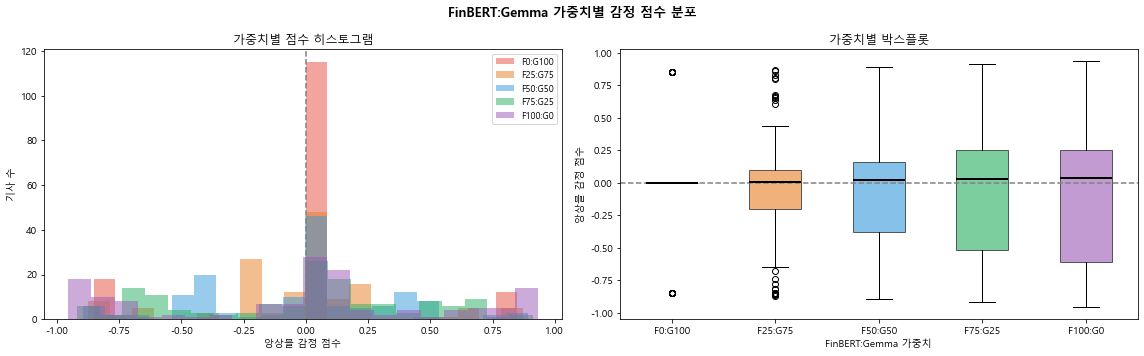


=== 가중치별 분포 지표 ===
             평균    표준편차     IQR      왜도      첨도
가중치                                            
F0:G100 -0.0352  0.3864  0.0000 -0.1704  1.8019
F25:G75 -0.0343  0.3509  0.2982 -0.1471  1.2210
F50:G50 -0.0335  0.3807  0.5427 -0.1619 -0.1637
F75:G25 -0.0327  0.4634  0.7756 -0.1474 -0.8688
F100:G0 -0.0319  0.5766  0.8673 -0.1077 -0.9443


In [9]:
# ── 가중치별 분포 시각화 ─────────────────────────────────────────────────
if not gemma_available or len(ensemble_results) <= 1:
    print('Gemma 미실행 — 가중치 비교 시각화를 건너뜁니다.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('FinBERT:Gemma 가중치별 감정 점수 분포', fontsize=13, fontweight='bold')

    colors = ['#e74c3c', '#e67e22', '#3498db', '#27ae60', '#9b59b6']
    labels_order = ['F0:G100', 'F25:G75', 'F50:G50', 'F75:G25', 'F100:G0']

    # 히스토그램
    ax = axes[0]
    for (label, res), color in zip(
        [(k, ensemble_results[k]) for k in labels_order if k in ensemble_results],
        colors
    ):
        ax.hist(res['ensemble_score'], bins=20, alpha=0.5, label=label, color=color)
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlabel('앙상블 감정 점수')
    ax.set_ylabel('기사 수')
    ax.set_title('가중치별 점수 히스토그램')
    ax.legend(fontsize=9)

    # 박스플롯
    ax = axes[1]
    data = [ensemble_results[k]['ensemble_score'].tolist()
            for k in labels_order if k in ensemble_results]
    bp = ax.boxplot(data, labels=[k for k in labels_order if k in ensemble_results],
                   patch_artist=True,
                   medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_xlabel('FinBERT:Gemma 가중치')
    ax.set_ylabel('앙상블 감정 점수')
    ax.set_title('가중치별 박스플롯')

    plt.tight_layout()
    plt.show()

    # 분포 지표 테이블
    print('\n=== 가중치별 분포 지표 ===')
    rows = []
    for label in labels_order:
        if label not in ensemble_results: continue
        s = ensemble_results[label]['ensemble_score']
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append({
            '가중치': label,
            '평균': round(s.mean(), 4),
            '표준편차': round(s.std(), 4),
            'IQR': round(q3 - q1, 4),
            '왜도': round(stats.skew(s), 4),
            '첨도': round(stats.kurtosis(s), 4),
        })
    print(pd.DataFrame(rows).set_index('가중치').to_string())
